# Batch Experiments for Hybrid ACO Algorithm

This notebook performs batch experiments to evaluate the performance of the Ant Colony Optimization (ACO) algorithm for the Capacitated Vehicle Routing Problem (CVRP).

The experiments:
- Run multiple ACO executions with different random seeds
- Compare results against Clarke & Wright heuristic
- Generate visualizations and statistics
- Track convergence behavior across iterations


## 1. Imports and Dependencies

Import all necessary libraries and modules for the experiments.


In [1]:
import statistics
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from aco_algo import AntColonyCVRP
from CW import (
    EDGE_WEIGHT,
    BEST_SOLUTION,
    capacity,
    clark_and_wright,
    data_set,
    demand,
    INSTANCE_PATH,
    total_travel_distance,
)


## 2. Configuration Parameters

Define the experimental setup:
- **NUM_RUNS**: Number of independent runs to perform
- **OUTPUT_DIR**: Directory where results and plots will be saved
- **ACO_PARAMS**: Parameters for the ACO algorithm (pheromone influence, evaporation rate, number of ants, etc.)


In [2]:
NUM_RUNS = 20
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ACO_PARAMS = {
    "dist_matrix": EDGE_WEIGHT,
    "demands": demand,
    "vehicle_capacity": capacity,
    "alpha": 2.0,
    "beta": 2.0,
    "rho": 0.15,
    "Q": 100,
    "num_ants": 30,
    "max_iter": 10,
    "local_search": True,
    "seed_strength": 600.0,
    "elitist_weight": 5.0,
    "start_with_cw_frac": 0.3,
    "candidate_list_size": 20,
    "tau_min": 1e-6,
    "tau_max": 1e3,
}


## 3. Batch Experiment Function

This function runs multiple ACO experiments and collects:
- **run_costs**: Best ACO costs before comparing against C&W
- **final_costs**: Final costs returned after possible C&W fallback
- **convergence_histories**: Evolution of the global best cost across iterations for each run

Each run uses a different random seed to ensure variability while maintaining reproducibility.


In [3]:
def run_batch_experiments(num_runs=NUM_RUNS):
    cw_solution = clark_and_wright()
    cw_cost = total_travel_distance(cw_solution)
    best_known_cost = total_travel_distance(BEST_SOLUTION)

    run_costs = []  # best ACO costs before comparing against C&W
    final_costs = []  # costs returned by run() after possible C&W fallback
    convergence_histories = []

    for run_idx in range(num_runs):
        seed = run_idx  # deterministic but different per run
        params = {**ACO_PARAMS, "rng_seed": seed}
        colony = AntColonyCVRP(**params)
        colony.cw_solution = deepcopy(cw_solution)

        _, best_cost_returned = colony.run(verbose=False)
        aco_cost = colony.best_cost_no_cw

        run_costs.append(aco_cost)
        final_costs.append(best_cost_returned)
        convergence_histories.append(list(colony.global_best_history))

        gap = (aco_cost - cw_cost) / cw_cost * 100.0
        print(
            f"Run {run_idx + 1}/{num_runs}: "
            f"ACO best={aco_cost:.2f} | "
            f"final={best_cost_returned:.2f} | "
            f"gap vs C&W={gap:.2f}%"
        )

    return {
        "cw_solution": cw_solution,
        "cw_cost": cw_cost,
        "best_known_cost": best_known_cost,
        "run_costs": run_costs,
        "final_costs": final_costs,
        "convergence": convergence_histories,
    }


## 4. Visualization Functions

### 4.1 Boxplot Visualization

Creates a boxplot showing the distribution of best ACO costs across all runs. This helps visualize the spread, median, and outliers of the results.


In [4]:
def plot_boxplots(results):
    run_costs = results["run_costs"]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.boxplot(run_costs, labels=["ACO best cost"], vert=True)
    ax.set_title("Distribution of best runs")
    ax.set_ylabel("Cost")
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "boxplot_aco_only.png", dpi=200)


### 4.2 Run Costs Visualization

Plots the cost for each individual run along with reference lines for:
- Mean cost (green solid line)
- Minimum cost (blue dashed line)
- Maximum cost (red dashed line)
- Clarke & Wright cost (purple dotted line) for comparison


In [5]:
def plot_run_costs(results):
    run_costs = np.array(results["run_costs"], dtype=float)
    cw_cost = results["cw_cost"]

    run_indices = np.arange(1, run_costs.size + 1)
    avg_cost = run_costs.mean()
    min_cost = run_costs.min()
    max_cost = run_costs.max()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(run_indices, run_costs, marker="o", label="Cost per run")
    ax.axhline(avg_cost, color="green", linestyle="-", label=f"Mean {avg_cost:.2f}")
    ax.axhline(min_cost, color="blue", linestyle="--", label=f"Min {min_cost:.2f}")
    ax.axhline(max_cost, color="red", linestyle="--", label=f"Max {max_cost:.2f}")
    ax.axhline(cw_cost, color="purple", linestyle=":", label=f"Clarke & Wright {cw_cost:.2f}")

    ax.set_xlabel("Test")
    ax.set_ylabel("Cost")
    ax.set_title("Run costs with average, min, max")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "run_costs.png", dpi=200)


### 4.3 Convergence Curves Visualization

Displays the convergence behavior of the ACO algorithm:
- Individual run curves (gray, semi-transparent)
- Mean convergence (blue solid line)
- Minimum convergence (green dashed line)
- Maximum convergence (red dashed line)

This helps understand how the algorithm improves over iterations and the variability between runs.


In [6]:
def plot_convergence(results):
    histories = results["convergence"]
    if not histories:
        return

    num_iters = len(histories[0])
    iterations = np.arange(1, num_iters + 1)
    history_matrix = np.array(histories)
    mean_history = history_matrix.mean(axis=0)
    min_history = history_matrix.min(axis=0)
    max_history = history_matrix.max(axis=0)

    fig, ax = plt.subplots(figsize=(10, 6))

    for idx, history in enumerate(histories, start=1):
        ax.plot(
            iterations,
            history,
            color="gray",
            alpha=0.3,
            linewidth=1,
        )

    ax.plot(iterations, mean_history, color="blue", linewidth=2, label="Mean")
    ax.plot(iterations, min_history, color="green", linestyle="--", linewidth=1.5, label="Min")
    ax.plot(iterations, max_history, color="red", linestyle="--", linewidth=1.5, label="Max")

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Global best cost")
    ax.set_title("ACO convergence curves")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "convergence_curves.png", dpi=200)


In [7]:
def write_statistics_file(results):
    run_costs = results["run_costs"]
    best_known_cost = results["best_known_cost"]
    
    median_cost = statistics.median(run_costs)
    median_gap = (median_cost - best_known_cost) / best_known_cost * 100.0
    
    best_cost = min(run_costs)
    best_gap = (best_cost - best_known_cost) / best_known_cost * 100.0
    
    worst_cost = max(run_costs)
    worst_gap = (worst_cost - best_known_cost) / best_known_cost * 100.0
    
    output_file = OUTPUT_DIR / "statistics.txt"
    with open(output_file, "w") as f:
        f.write(f"Median of cost | gap % compared to the best\n")
        f.write(f"{median_cost:.2f} | {median_gap:.2f}%\n\n")
        f.write(f"Worst gap/cost\n")
        f.write(f"{worst_gap:.2f}% / {worst_cost:.2f}\n\n")
        f.write(f"Best gap/cost\n")
        f.write(f"{best_gap:.2f}% / {best_cost:.2f}\n")
    
    print(f"\nStatistics saved to {output_file}")


## 6. Main Execution

Runs the complete batch experiment workflow:
1. Execute all ACO runs
2. Display performance summary
3. Generate all visualizations
4. Save statistics to file
5. Display plots


Run 1/20: ACO best=1090.14 | final=1071.07 | gap vs C&W=1.78%
Run 2/20: ACO best=1096.00 | final=1071.07 | gap vs C&W=2.33%
Run 3/20: ACO best=1110.56 | final=1071.07 | gap vs C&W=3.69%
Run 4/20: ACO best=1064.09 | final=1064.09 | gap vs C&W=-0.65%
Run 5/20: ACO best=1076.94 | final=1071.07 | gap vs C&W=0.55%
Run 6/20: ACO best=1098.94 | final=1071.07 | gap vs C&W=2.60%
Run 7/20: ACO best=1087.64 | final=1071.07 | gap vs C&W=1.55%
Run 8/20: ACO best=1051.72 | final=1051.72 | gap vs C&W=-1.81%
Run 9/20: ACO best=1109.99 | final=1071.07 | gap vs C&W=3.63%
Run 10/20: ACO best=1109.32 | final=1071.07 | gap vs C&W=3.57%
Run 11/20: ACO best=1121.85 | final=1071.07 | gap vs C&W=4.74%
Run 12/20: ACO best=1062.64 | final=1062.64 | gap vs C&W=-0.79%
Run 13/20: ACO best=1103.46 | final=1071.07 | gap vs C&W=3.02%
Run 14/20: ACO best=1051.97 | final=1051.97 | gap vs C&W=-1.78%
Run 15/20: ACO best=1083.68 | final=1071.07 | gap vs C&W=1.18%
Run 16/20: ACO best=1065.89 | final=1065.89 | gap vs C&W=-0.

C:\Users\nassim\AppData\Local\Temp\ipykernel_24432\1292747342.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(run_costs, labels=["ACO best cost"], vert=True)



Statistics saved to results\statistics.txt


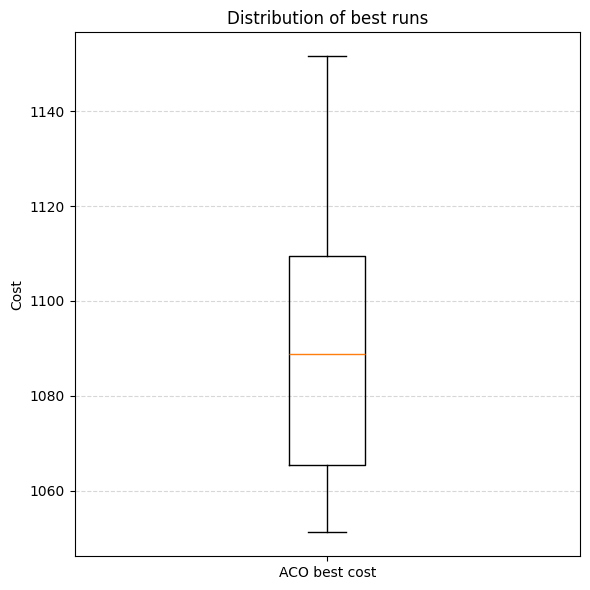

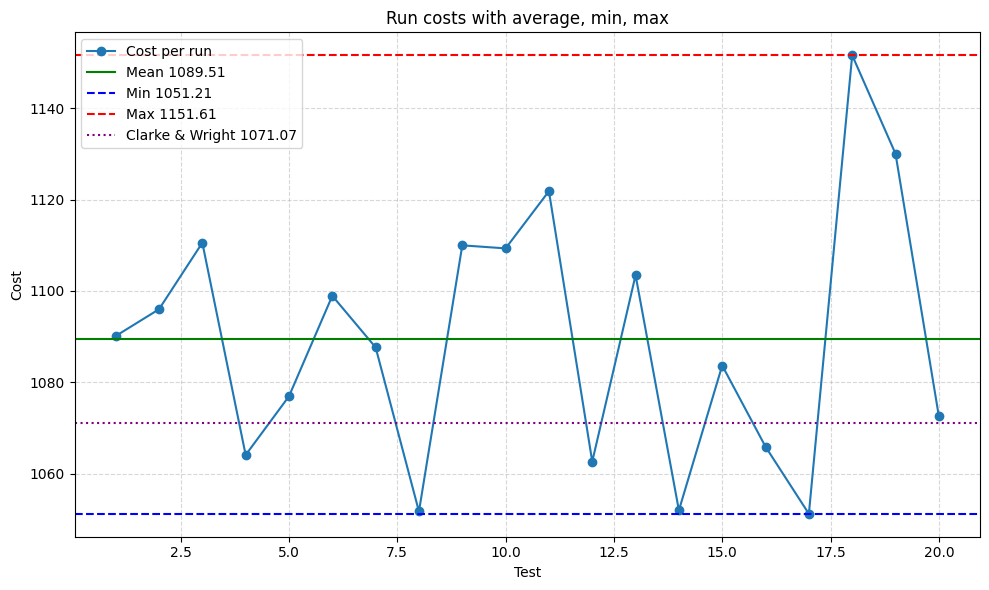

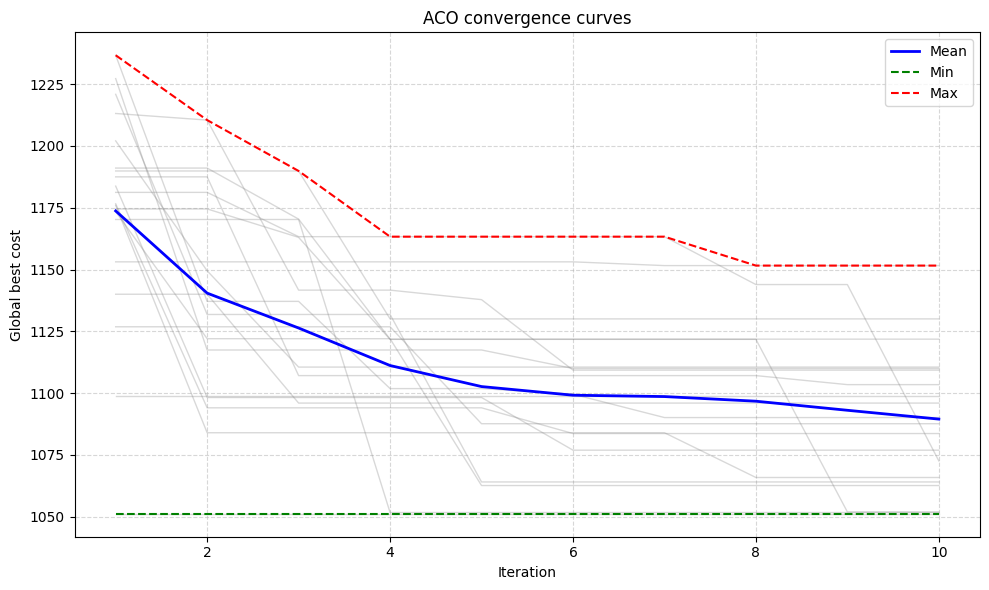

In [8]:
results = run_batch_experiments(NUM_RUNS)
print("\nPerformance summary")
print(f"Instance: {Path(INSTANCE_PATH).name}")
print(f"Clarke & Wright: {results['cw_cost']:.2f}")
print(f"Best ACO run: {min(results['run_costs']):.2f}")
print(f"Worst ACO run: {max(results['run_costs']):.2f}")
print(f"Mean ACO: {statistics.mean(results['run_costs']):.2f}")
print(f"Best-known cost (benchmark): {results['best_known_cost']:.2f}")

plot_boxplots(results)
plot_run_costs(results)
plot_convergence(results)
write_statistics_file(results)

plt.show()
